<a href="https://colab.research.google.com/github/nehavelmurugan14-oss/DAA-exp-1-/blob/main/DAA_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Array : [3, 1, 7, 4, 9, 2, 8, 5, 6, 0]
Minimum : 0
Maximum : 9
Divide & Conquer Comparisons : 14
Naive Comparisons : 18

    Size          D&C           Naive          3n/2-2
-------------------------------------------------------
      10           14              18              13
     100          162             198             148
    1000         1510            1998            1498
   10000        15902           19998           14998


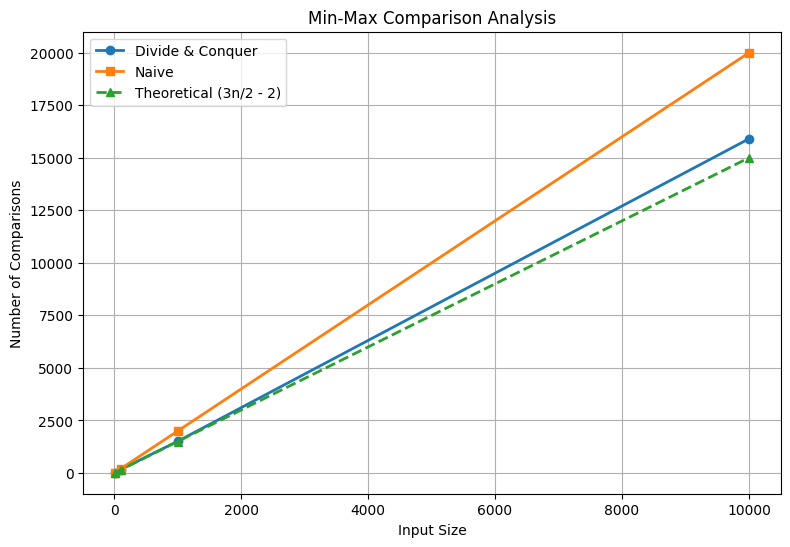

In [ ]:
import random
import matplotlib.pyplot as plt

# Global comparison counter
comparison_count = 0


# ---------------- Divide and Conquer ----------------
def min_max_dc(arr, low, high):
    global comparison_count

    # One element
    if low == high:
        return arr[low], arr[low]

    # Two elements
    if high == low + 1:
        comparison_count += 1
        if arr[low] < arr[high]:
            return arr[low], arr[high]
        else:
            return arr[high], arr[low]

    # Divide
    mid = (low + high) // 2

    left_min, left_max = min_max_dc(arr, low, mid)
    right_min, right_max = min_max_dc(arr, mid + 1, high)

    # Combine
    comparison_count += 1
    overall_min = left_min if left_min < right_min else right_min

    comparison_count += 1
    overall_max = left_max if left_max > right_max else right_max

    return overall_min, overall_max


# ---------------- Naive Method ----------------
def min_max_naive(arr):

    minimum = arr[0]
    maximum = arr[0]

    comparisons = 0

    for x in arr[1:]:

        comparisons += 1
        if x < minimum:
            minimum = x

        comparisons += 1
        if x > maximum:
            maximum = x

    return minimum, maximum, comparisons


# ---------------- Example ----------------
arr = [3, 1, 7, 4, 9, 2, 8, 5, 6, 0]

comparison_count = 0
minimum, maximum = min_max_dc(arr, 0, len(arr) - 1)
dc_comp = comparison_count

_, _, naive_comp = min_max_naive(arr)

print("Array :", arr)
print("Minimum :", minimum)
print("Maximum :", maximum)
print("Divide & Conquer Comparisons :", dc_comp)
print("Naive Comparisons :", naive_comp)


# ---------------- Performance Analysis ----------------

sizes = [10, 100, 1000, 10000]

dc_values = []
naive_values = []
formula_values = []

print("\n{:>8} {:>12} {:>15} {:>15}".format(
    "Size", "D&C", "Naive", "3n/2-2"))
print("-" * 55)

for size in sizes:

    arr = [random.randint(1, 10000) for _ in range(size)]

    comparison_count = 0

    min_max_dc(arr, 0, len(arr) - 1)

    dc = comparison_count

    _, _, naive = min_max_naive(arr)

    formula = 3 * size // 2 - 2

    dc_values.append(dc)
    naive_values.append(naive)
    formula_values.append(formula)

    print("{:>8} {:>12} {:>15} {:>15}".format(
        size, dc, naive, formula))


# ---------------- Graph ----------------

plt.figure(figsize=(9,6))

plt.plot(sizes, dc_values,
         marker='o',
         linewidth=2,
         label="Divide & Conquer")

plt.plot(sizes, naive_values,
         marker='s',
         linewidth=2,
         label="Naive")

plt.plot(sizes, formula_values,
         marker='^',
         linewidth=2,
         linestyle='--',
         label="Theoretical (3n/2 - 2)")

plt.title("Min-Max Comparison Analysis")
plt.xlabel("Input Size")
plt.ylabel("Number of Comparisons")
plt.legend()
plt.grid(True)

plt.show()